/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model bez regularyzacji:
Test loss: 0.0861, Test accuracy: 0.9600

Model z regularyzacją L1:
Test loss: 0.1745, Test accuracy: 0.9800

Model z regularyzacją L2:
Test loss: 0.0985, Test accuracy: 0.9700


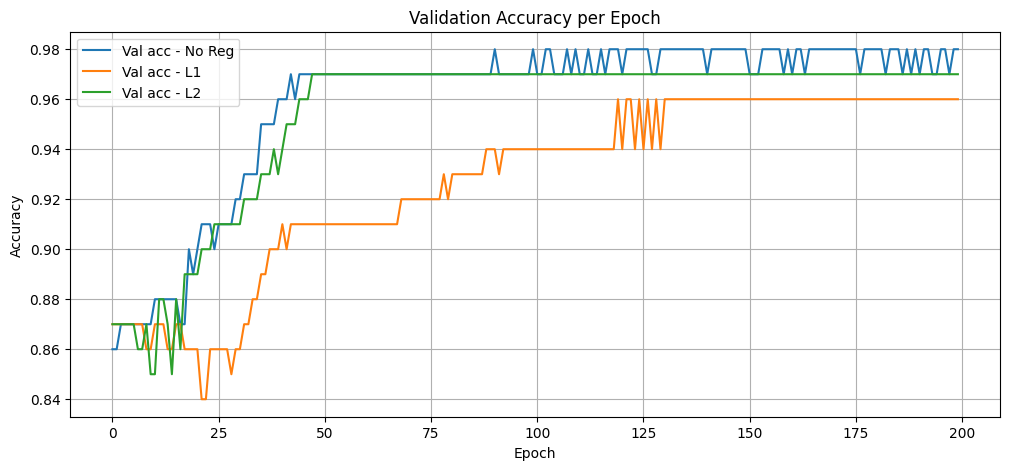

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# Generowanie danych
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Skalowanie danych
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Funkcja tworząca model
def create_model(l1=0.0, l2=0.0):
    model = Sequential([
        Dense(128, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2), input_shape=(2,)),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Trening modelu bez regularyzacji
model_no_reg = create_model()
history_no_reg = model_no_reg.fit(X_train_scaled, y_train, epochs=200, validation_data=(X_val_scaled, y_val), verbose=0)

# Trening modelu z regularyzacją L1
l1_factor = 0.001
model_l1 = create_model(l1=l1_factor)
history_l1 = model_l1.fit(X_train_scaled, y_train, epochs=200, validation_data=(X_val_scaled, y_val), verbose=0)

# Trening modelu z regularyzacją L2
l2_factor = 0.001
model_l2 = create_model(l2=l2_factor)
history_l2 = model_l2.fit(X_train_scaled, y_train, epochs=200, validation_data=(X_val_scaled, y_val), verbose=0)





✓ Zadanie 1. Co oznaczają i do czego służą zmienne l1 factor oraz l2 factor? Spróbuj dokonać kilku eksperymentów aby dobrać ich odpowiednie wartości.


In [3]:
l2_values = [0.0, 0.0001, 0.001, 0.01, 0.1]
for l2 in l2_values:
    model = create_model(l2=l2)
    model.fit(X_train_scaled, y_train, epochs=100, validation_data=(X_val_scaled, y_val), verbose=0)
    loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"L2={l2}: Test accuracy = {acc:.4f}")


L2=0.0: Test accuracy = 0.9700
L2=0.0001: Test accuracy = 0.9800
L2=0.001: Test accuracy = 0.9800
L2=0.01: Test accuracy = 0.9500
L2=0.1: Test accuracy = 0.8600


l1_factor – współczynnik regularyzacji L1 (Lasso),
l2_factor – współczynnik regularyzacji L2 (Ridge).

Te współczynniki określają siłę regularyzacji, czyli karę nakładaną na zbyt duże wagi w sieci neuronowej. Regularyzacja pomaga:zapobiegać przeuczeniu (overfittingowi),
wymuszać prostsze modele.
 L1 (l1_factor):
Dodaje do funkcji straty sumę wartości bezwzględnych wag.
Może prowadzić do zerowania nieistotnych wag → działa jak selekcja cech.

L2 (l2_factor):
Dodaje do funkcji straty sumę kwadratów wag.
Wygładza wagi, ale ich nie zeruje.


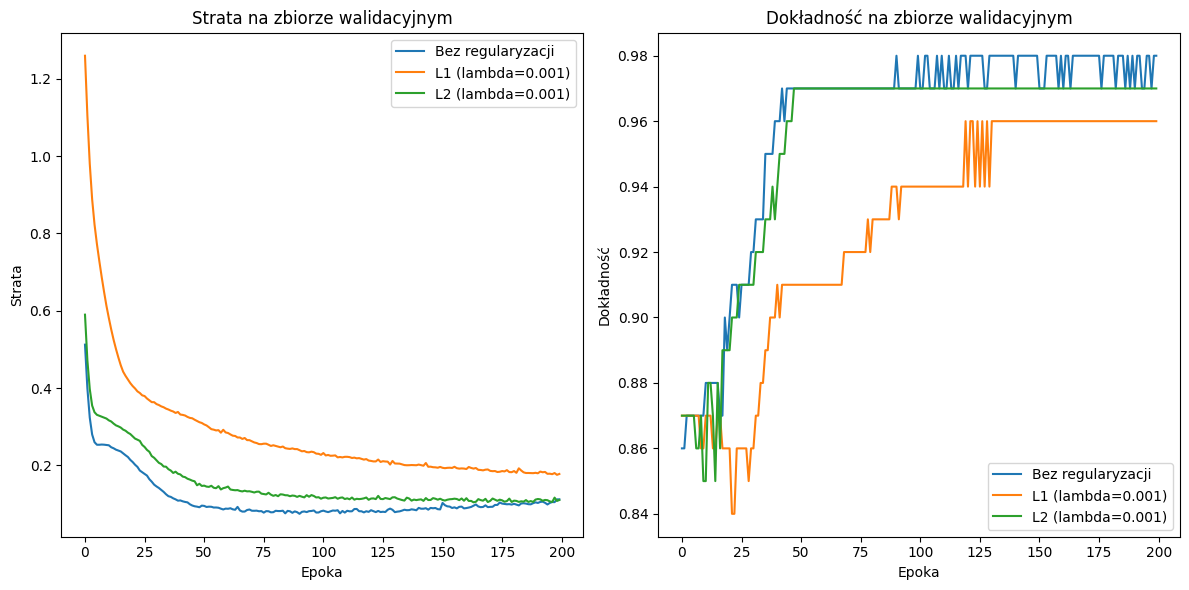


Norma L1 wag (bez regularyzacji): 1437.8374
Norma L2 wag (bez regularyzacji): 374.5457

Norma L1 wag (z regularyzacją L1): 122.5646
Norma L2 wag (z regularyzacją L1): 58.1498

Norma L1 wag (z regularyzacją L2): 403.3789
Norma L2 wag (z regularyzacją L2): 59.9922


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Rysowanie wykresów strat i dokładności
plt.figure(figsize=(12, 6))

# Wykres strat
plt.subplot(1, 2, 1)
plt.plot(history_no_reg.history['val_loss'], label='Bez regularyzacji')
plt.plot(history_l1.history['val_loss'], label=f'L1 (lambda={l1_factor})')
plt.plot(history_l2.history['val_loss'], label=f'L2 (lambda={l2_factor})')
plt.title('Strata na zbiorze walidacyjnym')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.legend()

# Wykres dokładności
plt.subplot(1, 2, 2)
plt.plot(history_no_reg.history['val_accuracy'], label='Bez regularyzacji')
plt.plot(history_l1.history['val_accuracy'], label=f'L1 (lambda={l1_factor})')
plt.plot(history_l2.history['val_accuracy'], label=f'L2 (lambda={l2_factor})')
plt.title('Dokładność na zbiorze walidacyjnym')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend()

plt.tight_layout()
plt.show()

# Obliczanie norm wag
l1_norm_no_reg = np.sum([np.sum(np.abs(w)) for w in model_no_reg.get_weights()])
l2_norm_no_reg = np.sum([np.sum(w ** 2) for w in model_no_reg.get_weights()])

l1_norm_l1 = np.sum([np.sum(np.abs(w)) for w in model_l1.get_weights()])
l2_norm_l1 = np.sum([np.sum(w ** 2) for w in model_l1.get_weights()])

l1_norm_l2 = np.sum([np.sum(np.abs(w)) for w in model_l2.get_weights()])
l2_norm_l2 = np.sum([np.sum(w ** 2) for w in model_l2.get_weights()])

# Wypisanie norm
print(f"\nNorma L1 wag (bez regularyzacji): {l1_norm_no_reg:.4f}")
print(f"Norma L2 wag (bez regularyzacji): {l2_norm_no_reg:.4f}")

print(f"\nNorma L1 wag (z regularyzacją L1): {l1_norm_l1:.4f}")
print(f"Norma L2 wag (z regularyzacją L1): {l2_norm_l1:.4f}")

print(f"\nNorma L1 wag (z regularyzacją L2): {l1_norm_l2:.4f}")
print(f"Norma L2 wag (z regularyzacją L2): {l2_norm_l2:.4f}")


Zadanie 2. Przeanalizuj otrzymane wartości norm. Jakie wnioski można z nich wyciągnąć? Co oznaczają poszczególne wartości norm 1. Regularyzacja istotnie ogranicza wartości wag
Wersja bez regularyzacji ma bardzo wysokie normy L1 i L2 – model nauczył się dużych wag, co często prowadzi do przeuczenia (overfittingu).

Zarówno L1, jak i L2 redukują te normy do znacznie niższych wartości – model jest bardziej „skompresowany”.

2. L1 działa silniej na redukcję normy L1 niż L2
Regularyzacja L1 bardzo mocno zmniejsza normę L1 (z ~1437 do ~123).

Dzieje się tak, ponieważ L1 zachęca do wyzerowania mniej istotnych wag – model staje się bardziej rzadki (sparse), co może prowadzić do selekcji cech.

3. L2 redukuje bardziej normę L2, ale mniej wpływa na normę L1
Regularyzacja L2 mocno ograniczyła normę L2 (z ~374 do ~60), ale norma L1 nadal jest wysoka (~403).

Oznacza to, że model nadal używa wielu cech, ale z mniejszymi wagami.

4. Porównanie L1 vs L2 – różne strategie uproszczenia
L1: prowadzi do wyzerowania niektórych wag → rzadki, prostszy model.

L2: prowadzi do równomiernego zmniejszenia wag → model jest nadal gęsty, ale "łagodniejszy".

3 Normalizacja wsadowa

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7442 - loss: 0.7136 - val_accuracy: 0.8609 - val_loss: 0.3853
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8697 - loss: 0.3614 - val_accuracy: 0.8886 - val_loss: 0.3134
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8878 - loss: 0.3093 - val_accuracy: 0.8972 - val_loss: 0.2881
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8977 - loss: 0.2784 - val_accuracy: 0.8890 - val_loss: 0.2992
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9085 - loss: 0.2522 - val_accuracy: 0.9010 - val_loss: 0.2742
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9154 - loss: 0.2341 - val_accuracy: 0.9082 - val_loss: 0.2547
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9201 - loss: 0.2211 - val_accuracy: 0.9020 - val_loss: 0.2684
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9269 - loss: 0.2018 -

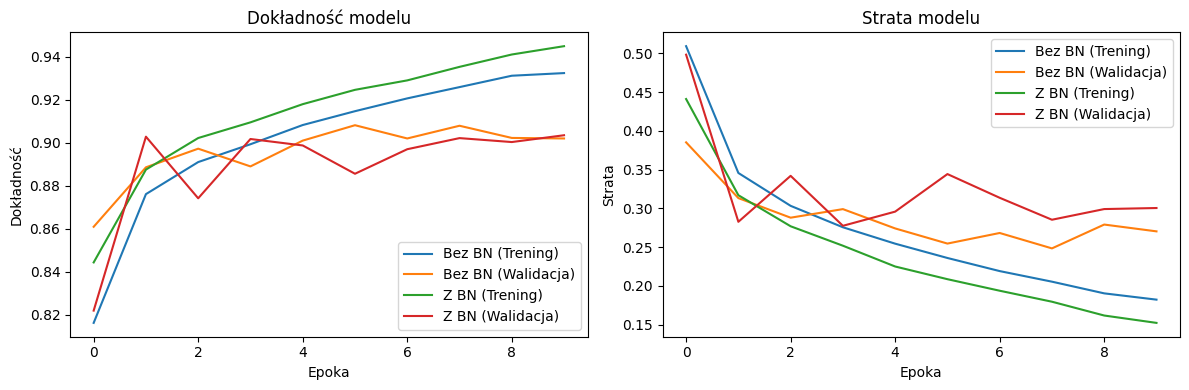

Model bez Batch Normalization: Dokładność testowa = 0.8993, Strata testowa = 0.2897
Model z Batch Normalization: Dokładność testowa = 0.8982, Strata testowa = 0.3322


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Wczytanie danych
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Przygotowanie danych
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255.0

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

# Podział na zbiór walidacyjny
val_split = 0.2
num_val_samples = int(len(train_images) * val_split)
val_images = train_images[:num_val_samples]
val_labels = train_labels[:num_val_samples]
partial_train_images = train_images[num_val_samples:]
partial_train_labels = train_labels[num_val_samples:]

# Model bez Batch Normalization
def create_model_no_bn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Model z Batch Normalization
def create_model_with_bn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Trening modeli
model_no_bn = create_model_no_bn()
history_no_bn = model_no_bn.fit(partial_train_images, partial_train_labels, epochs=10,
                                 validation_data=(val_images, val_labels), verbose=1)

model_with_bn = create_model_with_bn()
history_with_bn = model_with_bn.fit(partial_train_images, partial_train_labels, epochs=10,
                                     validation_data=(val_images, val_labels), verbose=1)

# Rysowanie wykresów
plt.figure(figsize=(12, 4))

# Dokładność
plt.subplot(1, 2, 1)
plt.plot(history_no_bn.history['accuracy'], label='Bez BN (Trening)')
plt.plot(history_no_bn.history['val_accuracy'], label='Bez BN (Walidacja)')
plt.plot(history_with_bn.history['accuracy'], label='Z BN (Trening)')
plt.plot(history_with_bn.history['val_accuracy'], label='Z BN (Walidacja)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.title('Dokładność modelu')
plt.legend()

# Strata
plt.subplot(1, 2, 2)
plt.plot(history_no_bn.history['loss'], label='Bez BN (Trening)')
plt.plot(history_no_bn.history['val_loss'], label='Bez BN (Walidacja)')
plt.plot(history_with_bn.history['loss'], label='Z BN (Trening)')
plt.plot(history_with_bn.history['val_loss'], label='Z BN (Walidacja)')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.title('Strata modelu')
plt.legend()

plt.tight_layout()
plt.show()

# Ocena modeli
loss_no_bn, accuracy_no_bn = model_no_bn.evaluate(test_images, test_labels, verbose=0)
print(f'Model bez Batch Normalization: Dokładność testowa = {accuracy_no_bn:.4f}, Strata testowa = {loss_no_bn:.4f}')

loss_with_bn, accuracy_with_bn = model_with_bn.evaluate(test_images, test_labels, verbose=0)
print(f'Model z Batch Normalization: Dokładność testowa = {accuracy_with_bn:.4f}, Strata testowa = {loss_with_bn:.4f}')


✓ Zadanie 3. Czy zastosowanie warstw normalizacji wsadowej wpływa na proces uczenia sieci neuronowej? Jeśli tak to w jaki sposób i jakich konsekwencji można oczekiwać po zastosowaniu normalizacji wsadowej? Jaki jest ostateczny wynik klasyfikacji?
Wpływ BN na proces uczenia:
Stabilizuje i przyspiesza trening przez zmniejszenie tzw. internal covariate shift — wartości aktywacji w warstwach ukrytych są bardziej przewidywalne.

Umożliwia użycie wyższego learning rate, co skraca czas trenowania.

Działa jak lekka forma regularyzacji, często zmniejszając potrzebę stosowania dropoutu lub silnej regularyzacji L2.

Model bez BN osiągnął nieco lepszy wynik testowy (dokładność: 0.8993 vs. 0.8982), ale niższą stratę (czyli lepsze dopasowanie).

W tym przypadku BN nie poprawiło końcowego wyniku, ale mogło poprawić stabilność i zbieżność treningu, co byłoby widoczne np. na wykresach strat/dokładności.

4 Wczesne zatrzymanie

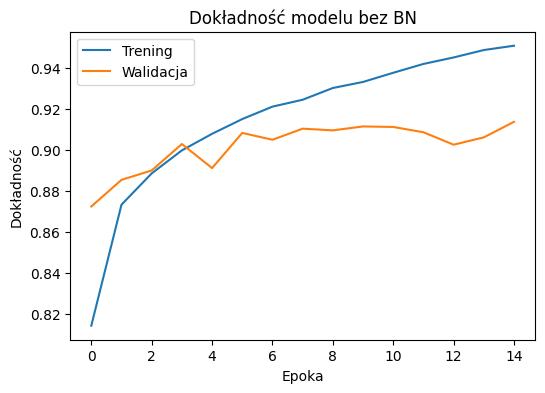

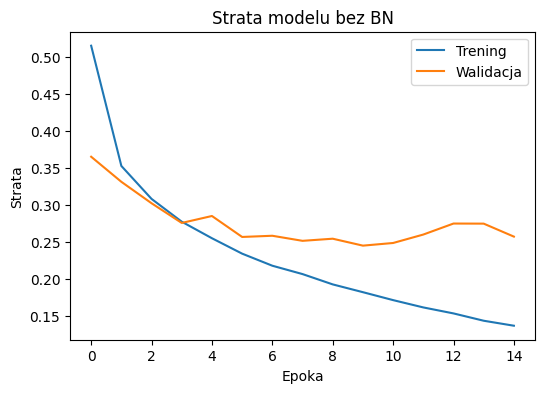

Model z wczesnym zatrzymaniem: Dokładność testowa = 0.9033, Strata testowa = 0.2810


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Załaduj i przygotuj zbiór danych Fashion-MNIST
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Dodaj wymiar kanału (dla Conv2D) i znormalizuj
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255.0

# Wydziel zbiór walidacyjny
val_split = 0.2
num_val_samples = int(len(train_images) * val_split)
val_images = train_images[:num_val_samples]
val_labels = train_labels[:num_val_samples]
partial_train_images = train_images[num_val_samples:]
partial_train_labels = train_labels[num_val_samples:]

# One-hot encoding etykiet
partial_train_labels = tf.keras.utils.to_categorical(partial_train_labels, num_classes=10)
val_labels = tf.keras.utils.to_categorical(val_labels, num_classes=10)
test_labels = tf.keras.utils.to_categorical(test_labels, num_classes=10)

# Definicja modelu bez Batch Normalization
def create_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Ustawienie wczesnego zatrzymania
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Trening modelu
model_no_bn = create_model()
history = model_no_bn.fit(
    partial_train_images, partial_train_labels,
    epochs=100,
    validation_data=(val_images, val_labels),
    verbose=0,
    callbacks=[early_stopping]
)

# Wizualizacja dokładności
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Trening')
plt.plot(history.history['val_accuracy'], label='Walidacja')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.title('Dokładność modelu bez BN')
plt.legend()
plt.show()

# Wizualizacja straty
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Trening')
plt.plot(history.history['val_loss'], label='Walidacja')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.title('Strata modelu bez BN')
plt.legend()
plt.show()

# Ocena na zbiorze testowym
loss, accuracy = model_no_bn.evaluate(test_images, test_labels, verbose=0)
print(f'Model z wczesnym zatrzymaniem: Dokładność testowa = {accuracy:.4f}, Strata testowa = {loss:.4f}')


Zadanie 4. Połącz wszystkie znane Ci techniki regularyzacji z tych oraz poprzednich zajęć do budowy końcowego kodu klasyfikacyjnego (dropout, augmentacja, normalizacja wsadowa, L1, L2, wczesne zatrzymanie). Spróbuj zbadać skuteczność modelu dla danych Fashion-MNIST przygotowanych w poprzednim przykładzie. Możesz spróbować dodać jeszcze jedną warstwę splotową do modelu (wraz z MaxPoolingiem, Dropout i normalizacją wsadową).

Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.6265 - loss: 1.2244 - val_accuracy: 0.8238 - val_loss: 0.5924
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7834 - loss: 0.7005 - val_accuracy: 0.8322 - val_loss: 0.5540
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8108 - loss: 0.6235 - val_accuracy: 0.8529 - val_loss: 0.5061
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8283 - loss: 0.5870 - val_accuracy: 0.8841 - val_loss: 0.4470
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8375 - loss: 0.5615 - val_accuracy: 0.8405 - val_loss: 0.5269
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8425 - loss: 0.5465 - val_accuracy: 0.8298 - val_loss: 0.5505
Epoch 7/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8513 - loss: 0.5318 - val_accuracy: 0.8878 - val_loss: 0.4279
Epoch 8/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8516 - loss: 0

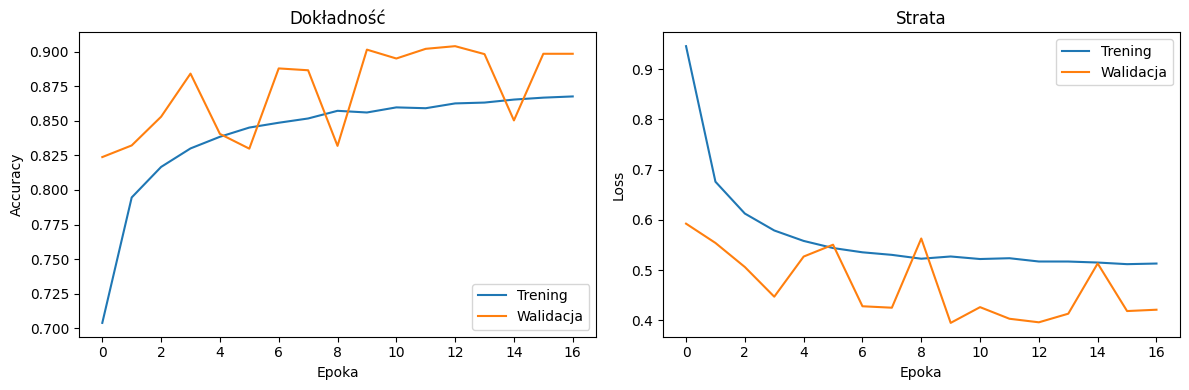

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Załaduj dane
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Przygotowanie danych
train_images = train_images.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

# One-hot encoding
train_labels_cat = tf.keras.utils.to_categorical(train_labels, 10)
test_labels_cat = tf.keras.utils.to_categorical(test_labels, 10)

# Podział na walidację
val_split = 0.2
num_val = int(len(train_images) * val_split)
val_images = train_images[:num_val]
val_labels_cat = train_labels_cat[:num_val]
partial_train_images = train_images[num_val:]
partial_train_labels_cat = train_labels_cat[num_val:]

# Augmentacja danych
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(partial_train_images)

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# Budowa modelu
def create_final_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4),
                      input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_final_model()

# Trening modelu z augmentacją
history = model.fit(
    datagen.flow(partial_train_images, partial_train_labels_cat, batch_size=64),
    epochs=100,
    validation_data=(val_images, val_labels_cat),
    callbacks=[early_stopping],
    verbose=1
)

# Ocena modelu
loss, accuracy = model.evaluate(test_images, test_labels_cat, verbose=0)
print(f"\n Dokładność testowa końcowego modelu: {accuracy:.4f}")
print(f" Strata testowa końcowego modelu: {loss:.4f}")

# Wykresy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Trening')
plt.plot(history.history['val_accuracy'], label='Walidacja')
plt.title('Dokładność')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Trening')
plt.plot(history.history['val_loss'], label='Walidacja')
plt.title('Strata')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
